<a href="https://colab.research.google.com/github/Ravilodugu12/TNS-practice-session/blob/main/netflix_data_visualization_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("netflix_titles.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'netflix_titles.csv'

### Data Overview

In [19]:
# Display basic information about the DataFrame
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


None

In [20]:
# Display descriptive statistics for numerical columns
display(df.describe())

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


### Initial Data Inspection

In [21]:
# Display the first 5 rows of the DataFrame
display(df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [22]:
# Check for missing values in each column
display(df.isnull().sum())

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


### Handle Missing Values

In [26]:
df.tail()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   object        
 1   type          8790 non-null   object        
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   cast          8790 non-null   object        
 5   country       8790 non-null   object        
 6   date_added    8790 non-null   datetime64[ns]
 7   release_year  8790 non-null   int64         
 8   rating        8790 non-null   object        
 9   duration      8790 non-null   object        
 10  listed_in     8790 non-null   object        
 11  description   8790 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 892.7+ KB


In [30]:
df = df.dropna(subset=['rating','date_added', 'date_added', 'duration'])

In [31]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df['cast'] = df['cast'].fillna("Unknown")
df['director'] = df['director'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")

In [32]:
# Which type of content is more available on Netflix?
stype = df['type'].value_counts()
stype

,count
type,
Movie,6126
TV Show,2664


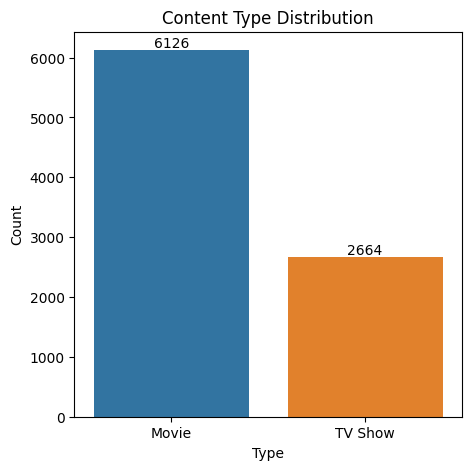

In [33]:
plt.figure(figsize=(5,5))
stype_df = stype.reset_index()
stype_df.columns = ['Type', 'Count']
ax = sns.barplot(x='Type', y='Count', hue = 'Type', data=stype_df)
plt.xlabel('Type')
plt.ylabel('Count')
plt.title('Content Type Distribution')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [34]:
# Which countries contribute the most content to Netflix?
countries = df['country'].apply(lambda x: str(x).split(', ')).explode()
country_counts = countries.value_counts()
if 'Unknown' in country_counts:
    country_counts = country_counts.drop('Unknown')
print('Top 10 Contributing Countries:')
display(country_counts.head(10))

Top 10 Contributing Countries:


,count
country,
United States,3680
India,1046
United Kingdom,803
Canada,445
France,393
Japan,316
Spain,232
South Korea,231
Germany,226


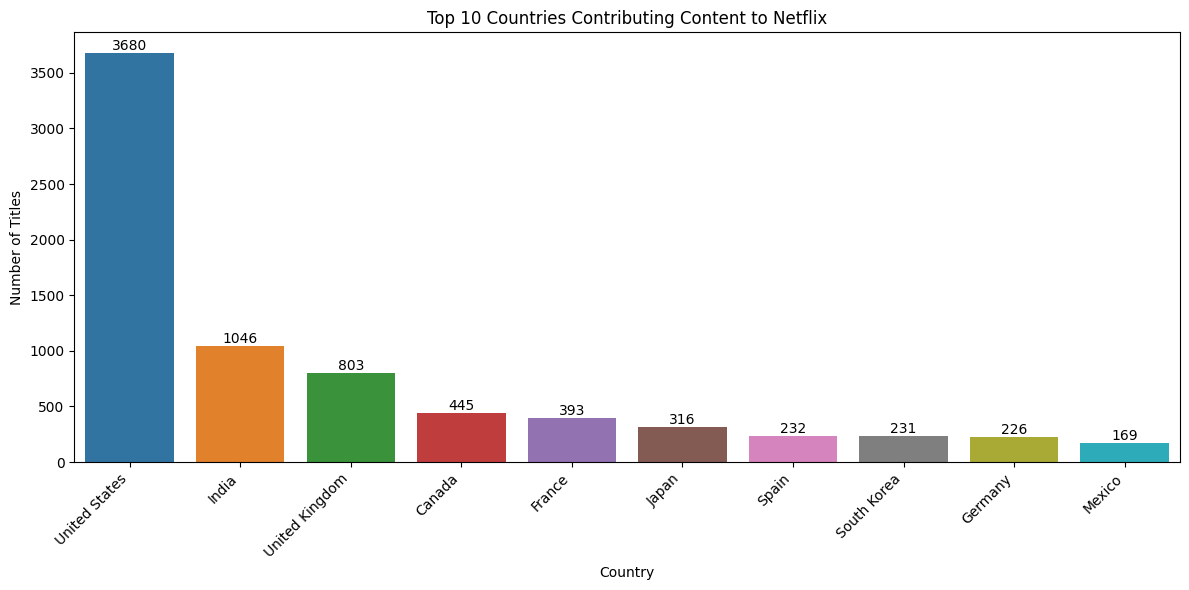

In [35]:
plt.figure(figsize=(12, 6))
top_countries = country_counts.head(10)
ax = sns.barplot(x=top_countries.index, y=top_countries.values, hue=top_countries.index, legend=False)
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.title('Top 10 Countries Contributing Content to Netflix')
plt.xticks(rotation=45, ha='right')
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [36]:
# Which directors have the most titles on Netflix?
directors = df['director'].apply(lambda x: str(x).split(', ')).explode()
director_counts = directors.value_counts()

if 'Unknown' in director_counts:
    director_counts = director_counts.drop('Unknown')

print('Top 10 Directors with Most Titles:')
display(director_counts.head(10))

Top 10 Directors with Most Titles:


,count
director,
Rajiv Chilaka,22
Jan Suter,21
Raúl Campos,19
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,15
Cathy Garcia-Molina,13
Martin Scorsese,12
Youssef Chahine,12


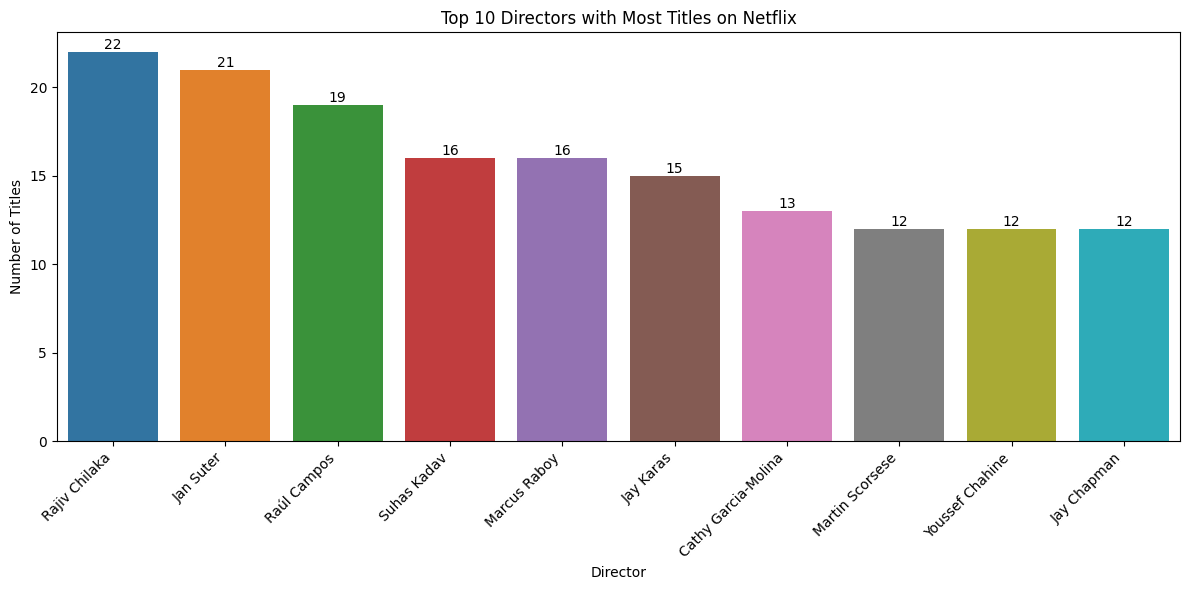

In [37]:
plt.figure(figsize=(12, 6))
top_directors = director_counts.head(10)
ax = sns.barplot(x=top_directors.index, y=top_directors.values, hue=top_directors.index, legend=False)
plt.xlabel('Director')
plt.ylabel('Number of Titles')
plt.title('Top 10 Directors with Most Titles on Netflix')
plt.xticks(rotation=45, ha='right')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()